In [1]:
import importlib
import classifier
importlib.reload(classifier)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from PIL import Image

from classifier import classify_image, compute_ecological_risk, preprocess_image, get_main_contour

# Global config
FOV_UM = 2000

print("✅ Setup complete")

✅ Setup complete


In [5]:
img_path = './samples/pellet.png'   # 👈 put exact file name here
img = Image.open(img_path)

result = classify_image(img, assumed_fov_um=FOV_UM)

print("✅ Single image test")
print("File:", img_path)
print("Type:", result.morphology)
print("Confidence:", result.confidence)
print("Risk:", result.risk_level)

✅ Single image test
File: ./samples/pellet.png
Type: Pellet/Microbead
Confidence: 0.95
Risk: 🟡 MODERATE


C:\Users\adik7\AppData\Local\Temp\ipykernel_34404\748466881.py:21: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adik7\AppData\Local\Temp\ipykernel_34404\748466881.py:22: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('./result_single.png', dpi=150)
C:\Users\adik7\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


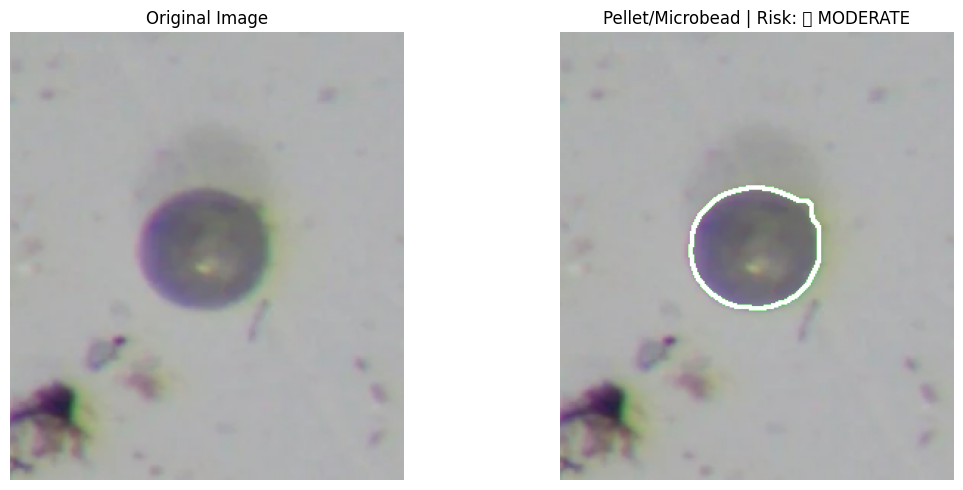

✅ Saved → result_single.png


In [6]:
img_np = np.array(img)
img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

thresh = preprocess_image(img_bgr)
contour = get_main_contour(thresh)

display_img = img_np.copy()
if contour is not None:
    cv2.drawContours(display_img, [contour], -1, (0,255,0), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(display_img)
axes[1].set_title(f"{result.morphology} | Risk: {result.risk_level}")
axes[1].axis('off')

plt.tight_layout()
plt.savefig('./result_single.png', dpi=150)
plt.show()

print("✅ Saved → result_single.png")

In [7]:
IMAGE_FOLDER = './samples/'
records      = []
valid_ext    = ('.jpg', '.jpeg', '.png')

files = [f for f in os.listdir(IMAGE_FOLDER) if f.lower().endswith(valid_ext)]
print(f"Found {len(files)} image(s)\n")

for fname in files:
    path = os.path.join(IMAGE_FOLDER, fname)
    img  = Image.open(path)

    r = classify_image(img, assumed_fov_um=FOV_UM)

    records.append({
        'Filename'      : fname,
        'Morphology'    : r.morphology,
        'Confidence_%'  : round(r.confidence * 100, 1),
        'Feret_um'      : r.feret_diameter_um,
        'Risk_Score'    : r.risk_score,
        'Risk_Level'    : r.risk_level,
        'Aspect_Ratio'  : r.aspect_ratio,
        'Solidity'      : r.solidity,
    })

    print(f"{fname:25s} → {r.morphology:18s} | ETI: {r.risk_score}")

df = pd.DataFrame(records)

print("\n✅ Done.")
df

Found 4 image(s)

fiber1 (2).png            → Film               | ETI: 30
film1.png                 → Film               | ETI: 30
fragment1.png             → Pellet/Microbead   | ETI: 35
pellet.png                → Pellet/Microbead   | ETI: 35

✅ Done.


,Filename,Morphology,Confidence_%,Feret_um,Risk_Score,Risk_Level,Aspect_Ratio,Solidity
0,fiber1 (2).png,Film,85.0,1994.29,30,🟢 LOW,1.38,0.74
1,film1.png,Film,85.0,1994.48,30,🟢 LOW,1.76,0.86
2,fragment1.png,Pellet/Microbead,60.0,923.17,35,🟡 MODERATE,1.40,0.92
3,pellet.png,Pellet/Microbead,95.0,651.69,35,🟡 MODERATE,1.06,0.99


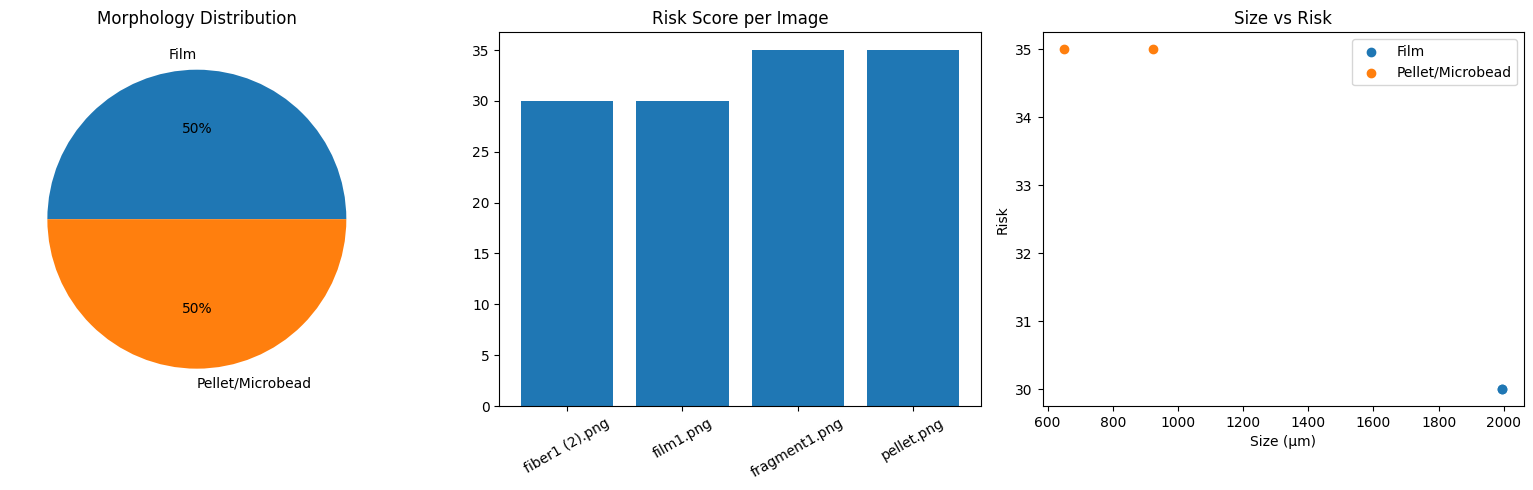

✅ Saved → batch_dashboard.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_map = {
    'Fiber'           : '#c084fc',
    'Fragment'        : '#86efac',
    'Film'            : '#7dd3f8',
    'Pellet/Microbead': '#fcd34d'
}

# PIE
morph_counts = df['Morphology'].value_counts()
axes[0].pie(morph_counts.values, labels=morph_counts.index, autopct='%1.0f%%')
axes[0].set_title('Morphology Distribution')

# BAR
axes[1].bar(df['Filename'], df['Risk_Score'])
axes[1].set_title('Risk Score per Image')
axes[1].tick_params(axis='x', rotation=30)

# SCATTER
for morph in df['Morphology'].unique():
    sub = df[df['Morphology'] == morph]
    axes[2].scatter(sub['Feret_um'], sub['Risk_Score'], label=morph)

axes[2].set_xlabel('Size (µm)')
axes[2].set_ylabel('Risk')
axes[2].legend()
axes[2].set_title('Size vs Risk')

plt.tight_layout()
plt.savefig('./batch_dashboard.png', dpi=150)
plt.show()

print("✅ Saved → batch_dashboard.png")

In [9]:
df.to_csv('./batch_report.csv', index=False)

print("✅ Saved → batch_report.csv")
df.describe()

✅ Saved → batch_report.csv


,Confidence_%,Feret_um,Risk_Score,Aspect_Ratio,Solidity
count,4.000000,4.000000,4.000000,4.000000,4.000000
mean,81.250000,1390.907500,32.500000,1.400000,0.877500
std,14.930394,705.594568,2.886751,0.286124,0.105948
min,60.000000,651.690000,30.000000,1.060000,0.740000
25%,78.750000,855.300000,30.000000,1.300000,0.830000
50%,85.000000,1458.730000,32.500000,1.390000,0.890000
75%,87.500000,1994.337500,35.000000,1.490000,0.937500
max,95.000000,1994.480000,35.000000,1.760000,0.990000


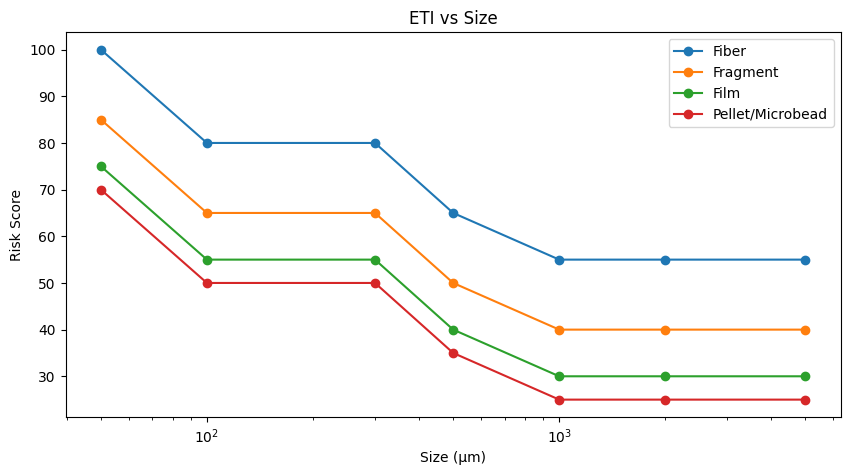

In [10]:
morphologies = ['Fiber', 'Fragment', 'Film', 'Pellet/Microbead']
sizes_um     = [50, 100, 300, 500, 1000, 2000, 5000]

plt.figure(figsize=(10,5))

for morph in morphologies:
    scores = [compute_ecological_risk(morph, s)[0] for s in sizes_um]
    plt.plot(sizes_um, scores, marker='o', label=morph)

plt.xscale('log')
plt.xlabel('Size (µm)')
plt.ylabel('Risk Score')
plt.title('ETI vs Size')
plt.legend()

plt.savefig('./eti_formula.png', dpi=150)
plt.show()

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#import seaborn as sns
import matplotlib.pyplot as plt



In [13]:
# Replace these lists with your actual values
y_true = np.array([0, 1, 1, 0, 2, 1, 0])   # True labels or actual ETI
y_pred = np.array([0, 1, 0, 0, 2, 1, 0])   # Predicted labels or predicted ETI

# For regression (continuous risk score)
y_true_reg = np.array([0.2, 0.8, 0.9, 0.1, 0.5])
y_pred_reg = np.array([0.25, 0.7, 0.95, 0.15, 0.55])

Accuracy: 0.8571428571428571
Precision: 0.8928571428571429
Recall: 0.8571428571428571
F1 Score: 0.8530612244897959

Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         1

    accuracy                           0.86         7
   macro avg       0.92      0.89      0.89         7
weighted avg       0.89      0.86      0.85         7



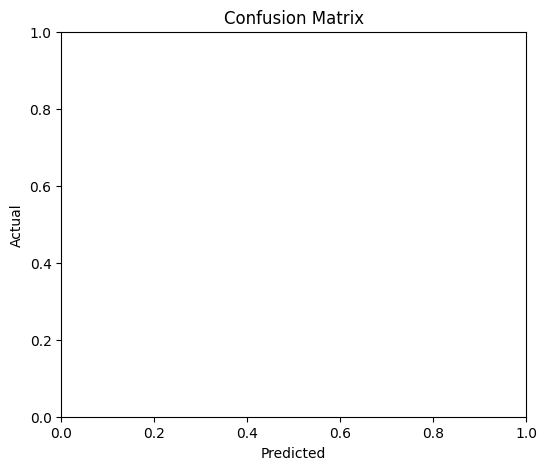

In [15]:
# Accuracy, Precision, Recall, F1-Score
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor  # For continuous Risk_Score
from sklearn.model_selection import train_test_split
import pickle

# Features and target
X = df[['Feret_um']]   # Add more features if available
y = df['Risk_Score']   # Continuous target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Save trained model
with open('microplastic_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Trained model saved → microplastic_model.pkl")

✅ Trained model saved → microplastic_model.pkl


In [20]:
import pandas as pd
import pickle

# Load your saved model
with open('microplastic_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Prepare input in the same format used during training
new_data = pd.DataFrame([[100]], columns=['Feret_um'])  # Example: Size = 100 µm

# Predict
pred = model.predict(new_data)
print("Predicted Risk Score:", pred)

Predicted Risk Score: [34.9]
